In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("results/results.csv")

df["guesser_label"] = df["guesser_model"].str.split("/").str[-1]
df["secret_label"]  = df["secret_model"].str.split("/").str[-1]
df["config"] = df["mode"] + "\n" + df["guesser_label"] + " / " + df["secret_label"]

df["avg_verified_win_score"] = df["judge_win_count"] / df["num_games"]

print(f"{len(df)} run(s) loaded")
df

36 run(s) loaded


,run_id,seed,mode,guesser_model,secret_model,num_games,num_wins,judge_win_count,avg_win_score,avg_efficiency_score,...,avg_diversity,energy_kwh,energy_per_game_wh,co2_g,co2_per_game_g,adjusted_co2_per_game_g,guesser_label,secret_label,config,avg_verified_win_score
0,slurm-batchmanual-1774991680-seed1-275,1,tool,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,9,1,1,0.111,0.111,...,0.1397,0.0,NaN,0.0,NaN,NaN,Qwen3.5-2B,Qwen3.5-2B,tool\nQwen3.5-2B / Qwen3.5-2B,0.111111
1,slurm-batchmanual-1774991680-seed10-284,10,tool,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,9,0,0,0.000,0.000,...,0.1582,0.0,NaN,0.0,NaN,NaN,Qwen3.5-2B,Qwen3.5-2B,tool\nQwen3.5-2B / Qwen3.5-2B,0.000000
2,slurm-batchmanual-1774991680-seed2-276,2,tool,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,9,0,0,0.000,0.000,...,0.1880,0.0,NaN,0.0,NaN,NaN,Qwen3.5-2B,Qwen3.5-2B,tool\nQwen3.5-2B / Qwen3.5-2B,0.000000
3,slurm-batchmanual-1774991680-seed3-277,3,tool,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,9,0,0,0.000,0.000,...,0.1413,0.0,NaN,0.0,NaN,NaN,Qwen3.5-2B,Qwen3.5-2B,tool\nQwen3.5-2B / Qwen3.5-2B,0.000000
4,slurm-batchmanual-1774991680-seed4-278,4,tool,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,9,0,1,0.000,0.000,...,0.1670,0.0,NaN,0.0,NaN,NaN,Qwen3.5-2B,Qwen3.5-2B,tool\nQwen3.5-2B / Qwen3.5-2B,0.111111
5,slurm-batchmanual-1774991680-seed5-279,5,tool,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,9,2,2,0.222,0.117,...,0.1937,0.0,NaN,0.0,NaN,NaN,Qwen3.5-2B,Qwen3.5-2B,tool\nQwen3.5-2B / Qwen3.5-2B,0.222222
6,slurm-batchmanual-1774991680-seed6-280,6,tool,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,9,0,0,0.000,0.000,...,0.1324,0.0,NaN,0.0,NaN,NaN,Qwen3.5-2B,Qwen3.5-2B,tool\nQwen3.5-2B / Qwen3.5-2B,0.000000
7,slurm-batchmanual-1774991680-seed7-281,7,tool,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,9,0,0,0.000,0.000,...,0.1665,0.0,NaN,0.0,NaN,NaN,Qwen3.5-2B,Qwen3.5-2B,tool\nQwen3.5-2B / Qwen3.5-2B,0.000000
8,slurm-batchmanual-1774991680-seed8-282,8,tool,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,9,0,0,0.000,0.000,...,0.1117,0.0,NaN,0.0,NaN,NaN,Qwen3.5-2B,Qwen3.5-2B,tool\nQwen3.5-2B / Qwen3.5-2B,0.000000
9,slurm-batchmanual-1774991680-seed9-283,9,tool,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,9,2,1,0.222,0.044,...,0.1443,0.0,NaN,0.0,NaN,NaN,Qwen3.5-2B,Qwen3.5-2B,tool\nQwen3.5-2B / Qwen3.5-2B,0.111111


## 1 — Win rate by mode & model
Shows how often the guesser wins across different configurations. When multiple seeds exist, bars show the mean and error bars show standard deviation.

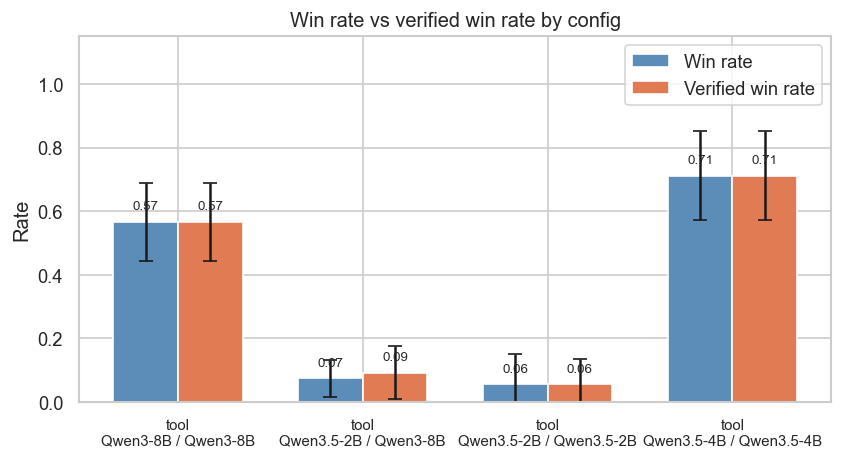

In [16]:
grouped = df.groupby("config")[["avg_win_score", "avg_verified_win_score"]].agg(["mean", "std"]).reset_index()
grouped.columns = ["config", "win_mean", "win_std", "verified_mean", "verified_std"]
grouped[["win_std", "verified_std"]] = grouped[["win_std", "verified_std"]].fillna(0)

x = np.arange(len(grouped))
width = 0.35
fig, ax = plt.subplots(figsize=(max(7, len(grouped) * 1.8), 4))

bars1 = ax.bar(x - width/2, grouped["win_mean"], width, yerr=grouped["win_std"],
               capsize=4, label="Win rate", color="#5b8db8", edgecolor="white")
bars2 = ax.bar(x + width/2, grouped["verified_mean"], width, yerr=grouped["verified_std"],
               capsize=4, label="Verified win rate", color="#e07b54", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(grouped["config"], fontsize=9)
ax.set_ylabel("Rate")
ax.set_ylim(0, 1.15)
ax.set_title("Win rate vs verified win rate by config")
ax.legend()

for bar, val in zip(bars1, grouped["win_mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars2, grouped["verified_mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 2 — Score breakdown per config
Compares all evaluation metrics side by side. Good for spotting whether a model is strong at one layer but weak at another.

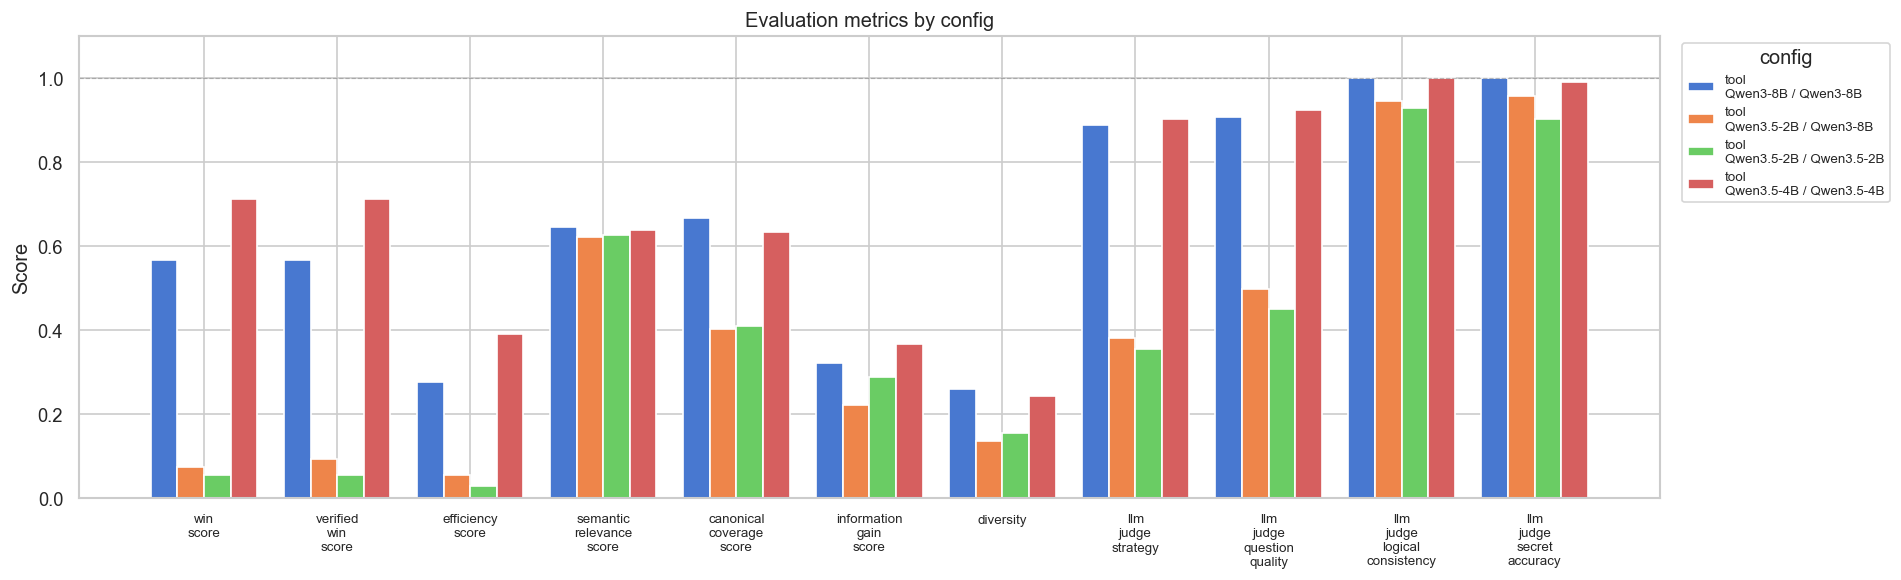

In [17]:
metrics = [
    "avg_win_score", "avg_verified_win_score", "avg_efficiency_score",
    "avg_semantic_relevance_score", "avg_canonical_coverage_score",
    "avg_information_gain_score", "avg_diversity",
    "avg_llm_judge_strategy", "avg_llm_judge_question_quality",
    "avg_llm_judge_logical_consistency", "avg_llm_judge_secret_accuracy",
]
labels = [m.replace("avg_", "").replace("_", "\n") for m in metrics]

mean_df = df.groupby("config")[metrics].mean()

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(metrics))
width = 0.8 / max(len(mean_df), 1)
colors = sns.color_palette("muted", len(mean_df))

for i, (config, row) in enumerate(mean_df.iterrows()):
    offset = (i - len(mean_df)/2 + 0.5) * width
    ax.bar(x + offset, row[metrics], width=width, label=config, color=colors[i], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Evaluation metrics by config")
ax.legend(title="config", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.show()

## 3 — Seed variance (stability across runs)
When you have multiple seeds per config, this shows how stable the results are. High variance = the model is sensitive to random seed.

/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_64835/42427544.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=configs_with_seeds, x="config", y=metric, ax=ax, palette="muted")
/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_64835/42427544.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=configs_with_seeds, x="config", y=metric, ax=ax, palette="muted")
/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_64835/42427544.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=configs_with_seeds,

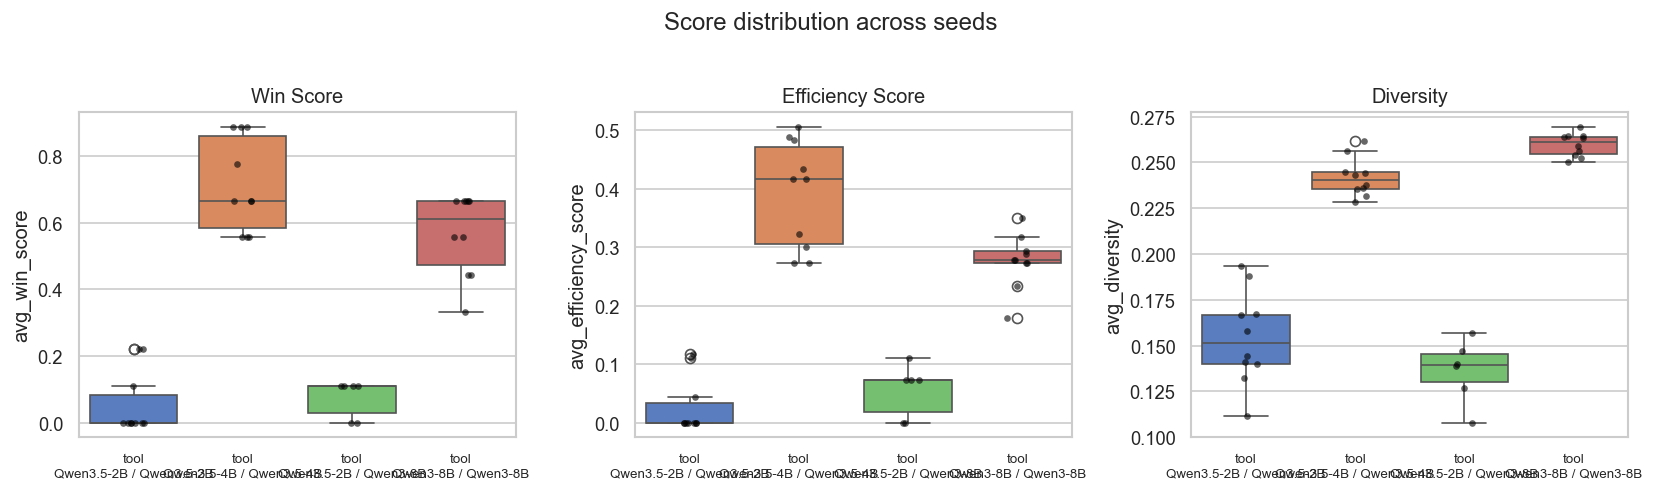

In [18]:
seed_metrics = ["avg_win_score", "avg_efficiency_score", "avg_diversity"]

configs_with_seeds = df.groupby("config").filter(lambda x: len(x) > 1)

if configs_with_seeds.empty:
    print("Need multiple seeds per config to show variance. Run submit_bulk_seeds.sh first.")
else:
    fig, axes = plt.subplots(1, len(seed_metrics), figsize=(14, 4), sharey=False)
    for ax, metric in zip(axes, seed_metrics):
        sns.boxplot(data=configs_with_seeds, x="config", y=metric, ax=ax, palette="muted")
        sns.stripplot(data=configs_with_seeds, x="config", y=metric, ax=ax,
                      color="black", size=4, alpha=0.6, jitter=True)
        ax.set_title(metric.replace("avg_", "").replace("_", " ").title())
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=8)
    plt.suptitle("Score distribution across seeds", y=1.02)
    plt.tight_layout()
    plt.show()

## 4 — Carbon footprint
CO2 per game and total energy by config. Useful for comparing the environmental cost of larger vs smaller models.

In [19]:
carbon = df.groupby("config")[["co2_per_game_g", "energy_per_game_wh"]].mean().reset_index()
carbon

,config,co2_per_game_g,energy_per_game_wh
0,tool\nQwen3-8B / Qwen3-8B,NaN,NaN
1,tool\nQwen3.5-2B / Qwen3-8B,NaN,NaN
2,tool\nQwen3.5-2B / Qwen3.5-2B,NaN,NaN
3,tool\nQwen3.5-4B / Qwen3.5-4B,NaN,NaN


/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_64835/4230782925.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
posx and posy should be finite values
posx and posy should be finite values
/Users/jakobahlberg/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
posx and posy should be finite values
posx and posy should be finite values


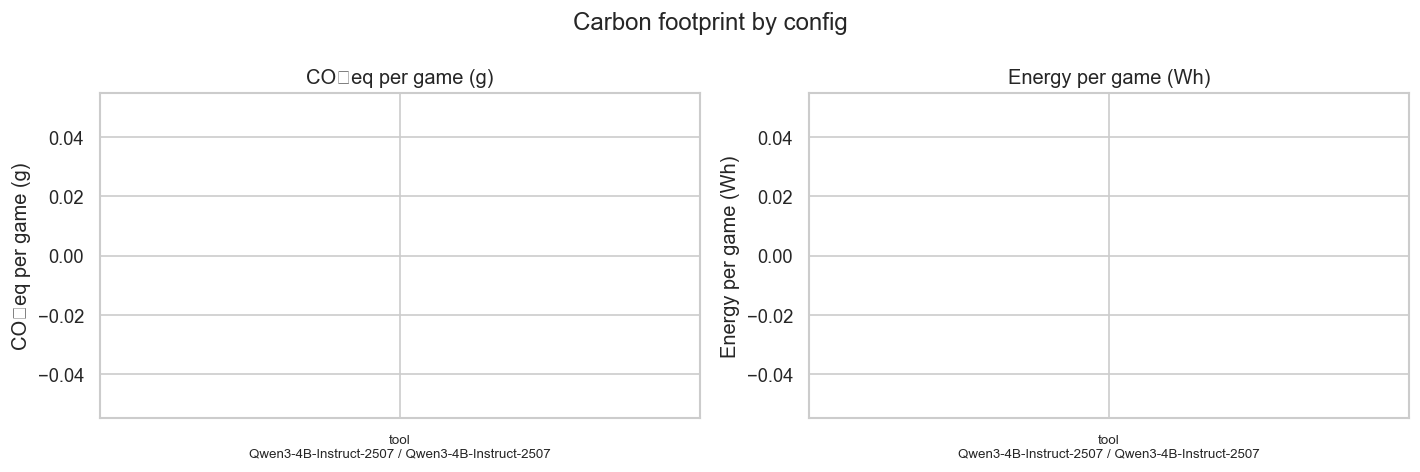

In [8]:
carbon = df.groupby("config")[["co2_per_game_g", "energy_per_game_wh"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label, color in zip(
    axes,
    ["co2_per_game_g", "energy_per_game_wh"],
    ["CO₂eq per game (g)", "Energy per game (Wh)"],
    ["#e07b54", "#5b8db8"],
):
    bars = ax.bar(carbon["config"], carbon[col], color=color, edgecolor="white")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.tick_params(axis="x", labelsize=8)
    for bar, val in zip(bars, carbon[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(carbon[col])*0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Carbon footprint by config")
plt.tight_layout()
plt.show()

## 5 — Win rate vs CO₂ (efficiency frontier)
Is the better-performing model worth the extra carbon cost? Points in the top-left are ideal (high win rate, low CO₂).

/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_64835/101462640.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/jakobahlberg/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


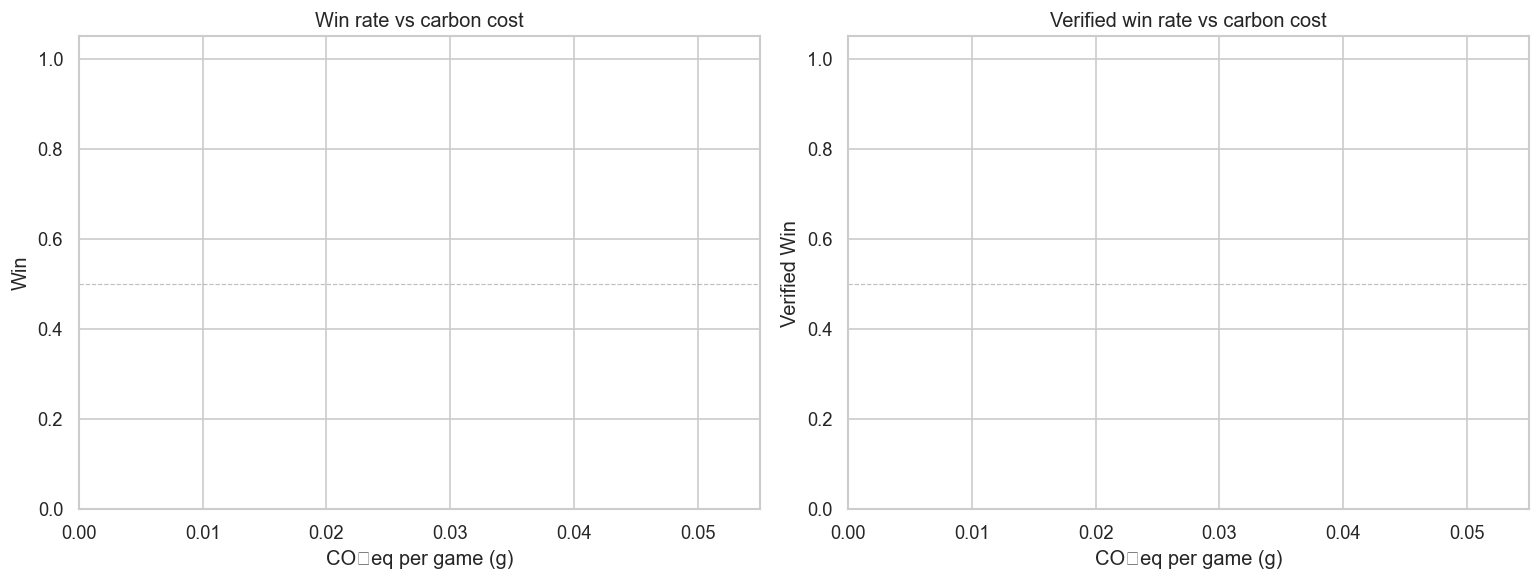

In [11]:
scatter = df.groupby("config").agg(
    win=("avg_win_score", "mean"),
    verified_win=("avg_verified_win_score", "mean"),
    co2=("co2_per_game_g", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette("muted", len(scatter))

for ax, y_col, title in zip(
    axes,
    ["win", "verified_win"],
    ["Win rate vs carbon cost", "Verified win rate vs carbon cost"],
):
    for i, row in scatter.iterrows():
        ax.scatter(row["co2"], row[y_col], s=120, color=colors[i], zorder=3)
        ax.annotate(row["config"], (row["co2"], row[y_col]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.set_xlabel("CO₂eq per game (g)")
    ax.set_ylabel(y_col.replace("_", " ").title())
    ax.set_title(title)
    ax.set_xlim(left=0)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)

plt.tight_layout()
plt.show()

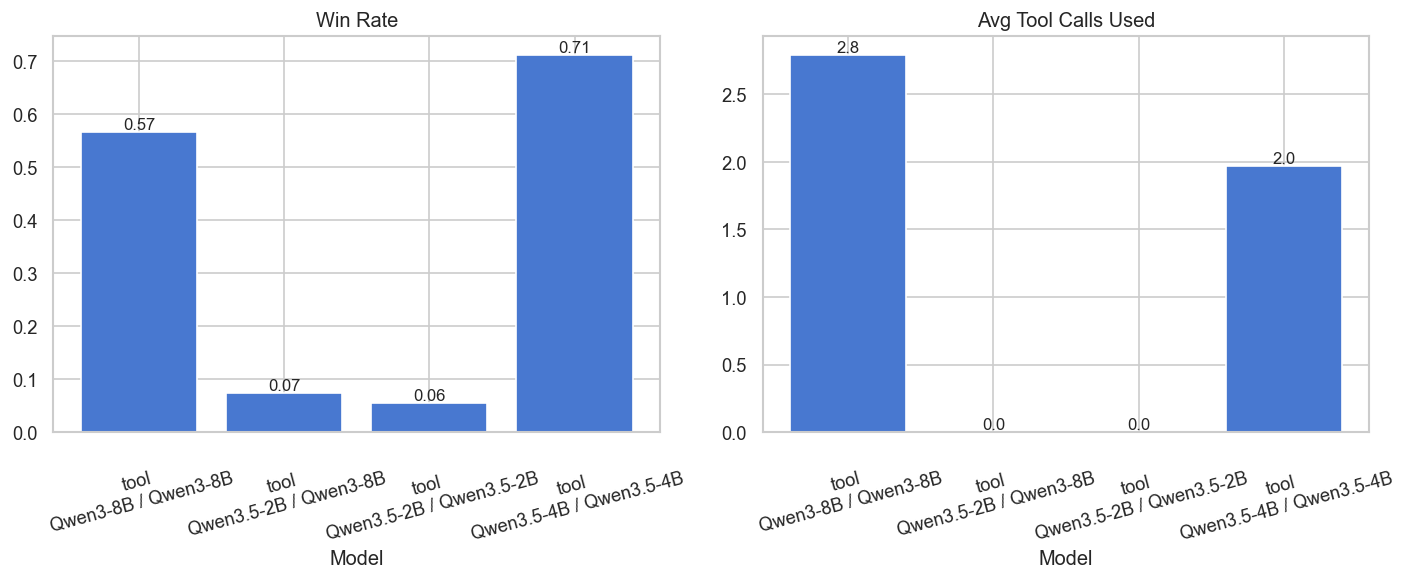

In [23]:
agg = df.groupby("config").agg(                                                        
    winrate=("avg_win_score", "mean"),                                                 
    tool_calls=("avg_tool_calls_used", "mean"),                                        
).reset_index()                                                                        
                                                                                        
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                                                                                        
for ax, col, title, fmt in [                                                           
    (axes[0], "winrate",    "Win Rate",          "{:.2f}"),
    (axes[1], "tool_calls", "Avg Tool Calls Used", "{:.1f}"),                          
]:                                                                                     
    bars = ax.bar(agg["config"], agg[col])                                             
    for bar, val in zip(bars, agg[col]):                                               
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                fmt.format(val), ha="center", va="bottom", fontsize=10)                
    ax.set_title(title)
    ax.set_xlabel("Model")                                                             
    ax.tick_params(axis="x", rotation=15)
                                                                                        
plt.tight_layout()
plt.show()

## 7 — Metric correlation heatmap
Which metrics tend to move together? Helps understand whether the evaluation layers are measuring different things or overlapping.

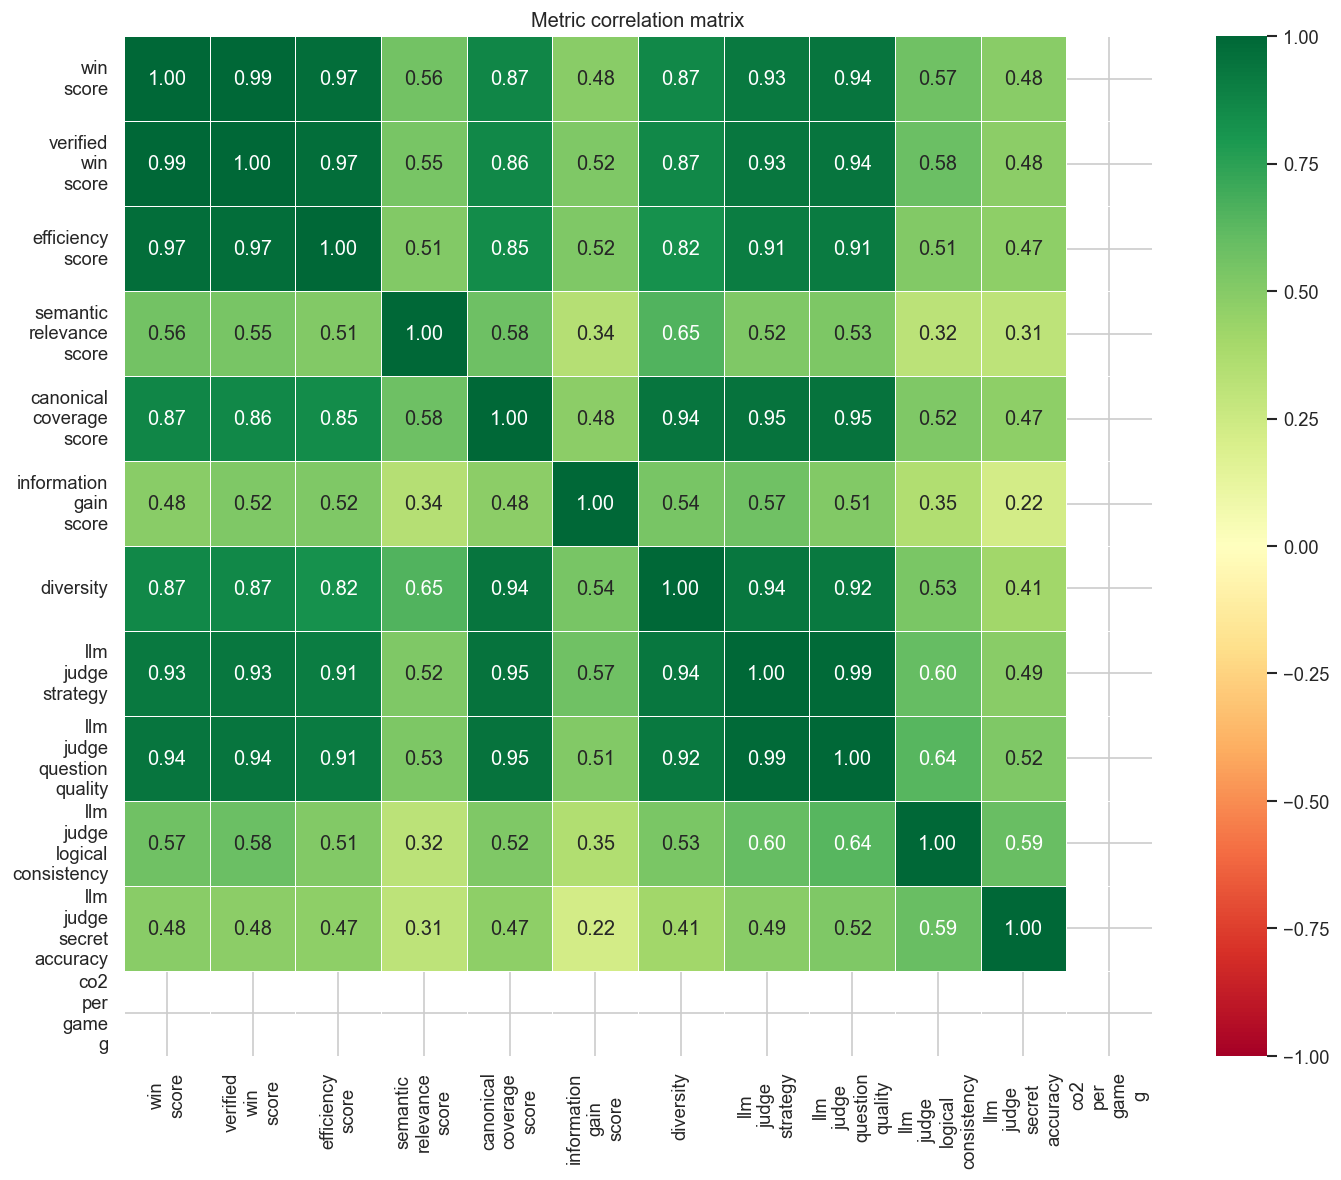

In [21]:
if len(df) < 3:
    print("Need at least 3 runs to compute meaningful correlations.")
else:
    corr_cols = [
        "avg_win_score", "avg_verified_win_score", "avg_efficiency_score",
        "avg_semantic_relevance_score", "avg_canonical_coverage_score",
        "avg_information_gain_score", "avg_diversity",
        "avg_llm_judge_strategy", "avg_llm_judge_question_quality",
        "avg_llm_judge_logical_consistency", "avg_llm_judge_secret_accuracy",
        "co2_per_game_g",
    ]
    corr = df[corr_cols].corr()
    short = [c.replace("avg_", "").replace("_", "\n") for c in corr_cols]

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                xticklabels=short, yticklabels=short,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title("Metric correlation matrix")
    plt.tight_layout()
    plt.show()

## 8 — Quantization comparison heatmaps
For runs where the same model family is used for both guesser and secret keeper but with different quantizations (e.g. 4bit, 8bit, base), each cell shows the mean verified win rate for that (guesser quant × secret quant) pairing. One heatmap per model family.

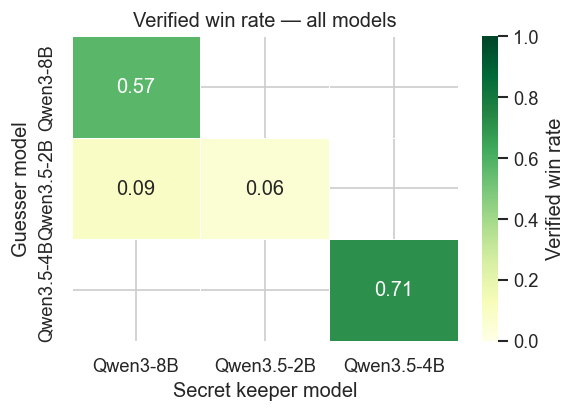

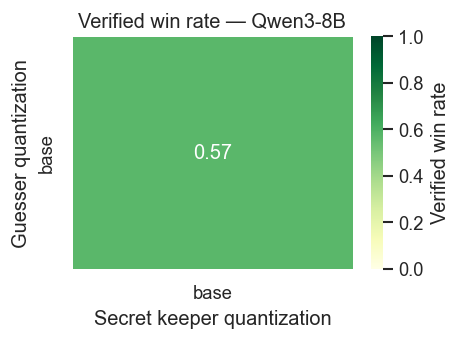

In [22]:
# ── Quantization config — fill in your model IDs here ───────────────────────
# Each key is a model family name (used as the heatmap title).
# Each value maps quantization label → exact model ID used in config.py.
# Add as many families and quant levels as you like.

QUANT_FAMILIES = {
    "Qwen3-8B": {
        "base": "Qwen/Qwen3-8B",
        "4bit": "your-org/Qwen3-8B-4bit",   # replace with actual model IDs
        "8bit": "your-org/Qwen3-8B-8bit",
    },
    # "Llama-3-8B": {
    #     "base": "meta-llama/Meta-Llama-3-8B",
    #     "4bit": "your-org/Llama-3-8B-4bit",
    # },
}

# ─────────────────────────────────────────────────────────────────────────────

# Overall model-family heatmap (uses guesser_label / secret_label from setup cell)
overall_pivot = (
    df.groupby(["guesser_label", "secret_label"])["avg_verified_win_score"]
    .mean()
    .unstack()
)

if overall_pivot.shape[0] >= 1 and overall_pivot.shape[1] >= 1:
    fig, ax = plt.subplots(
        figsize=(max(5, overall_pivot.shape[1] * 1.6),
                 max(3, overall_pivot.shape[0] * 1.2))
    )
    sns.heatmap(
        overall_pivot, annot=True, fmt=".2f", cmap="YlGn",
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
        cbar_kws={"label": "Verified win rate"},
    )
    ax.set_xlabel("Secret keeper model")
    ax.set_ylabel("Guesser model")
    ax.set_title("Verified win rate — all models")
    plt.tight_layout()
    plt.show()

# Per-family quantization heatmaps
for family_name, quant_map in QUANT_FAMILIES.items():
    # Invert: model_id → quant label
    id_to_quant = {v: k for k, v in quant_map.items()}

    sub = df[
        df["guesser_model"].isin(id_to_quant) &
        df["secret_model"].isin(id_to_quant)
    ].copy()

    if sub.empty:
        print(f"[{family_name}] No matching runs found — check model IDs in QUANT_FAMILIES.")
        continue

    sub["guesser_quant"] = sub["guesser_model"].map(id_to_quant)
    sub["secret_quant"]  = sub["secret_model"].map(id_to_quant)

    pivot = (
        sub.groupby(["guesser_quant", "secret_quant"])["avg_verified_win_score"]
        .mean()
        .unstack()
    )

    # Preserve order as defined in QUANT_FAMILIES
    quant_order = list(quant_map.keys())
    row_order = [q for q in quant_order if q in pivot.index]
    col_order = [q for q in quant_order if q in pivot.columns]
    pivot = pivot.reindex(index=row_order, columns=col_order)

    fig, ax = plt.subplots(
        figsize=(max(4, len(col_order) * 1.6), max(3, len(row_order) * 1.2))
    )
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="YlGn",
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
        cbar_kws={"label": "Verified win rate"},
    )
    ax.set_xlabel("Secret keeper quantization")
    ax.set_ylabel("Guesser quantization")
    ax.set_title(f"Verified win rate — {family_name}")
    plt.tight_layout()
    plt.show()